# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* `gym-classics2` (see [Installation instructions](../common/Setup_gym_classics2.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [3]:
from gym_classics2.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self, tabular=True):
        super().__init__(self.layout, tabular=tabular)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

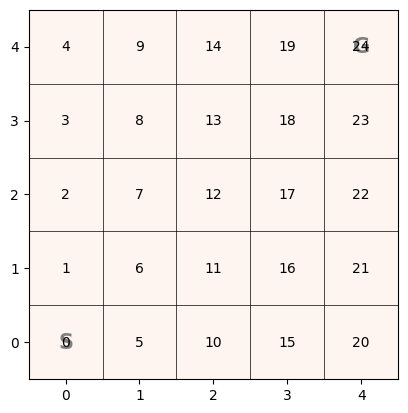

In [4]:
gym_env = gym.make('EmptyGridworld-v1', tabular = False)
env = gym_env.unwrapped

env.image()

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`


In [5]:
def state_features(s, env):
    coord = s
    return np.concatenate([np.array([1]), np.array(coord)])

In [6]:
display(state_features((0, 0), env))
display(state_features((0, 1), env))

array([1, 0, 0])

array([1, 0, 1])

# Control: Semi-Gradient Sarsa

This is an on-policy control algorithm which has the following implications:

* It is required that the algorithm keeps exploring. We accomplish that by using an $\epsilon$-greedy. 
* This means we will not find the optimal deterministic policy, but the best $\epsilon$-greedy policy and its approximate value function.


![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) 
suggest to use a state feature vectors to construct the complete 
state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only the intercept and the weights belonging to the action are used for prediction nd in the update.

In [7]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [8]:
def q_hat(s, a, w, env): 
    return np.dot(w[active_weights(a)], state_features(s, env))

In [9]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat((2,1), 2, w,env)

np.int64(13)

In [10]:
from tqdm import tqdm

def semi_gradient_Sarsa_0(env, n, epsilon, alpha, gamma, w = None, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"

    if w is None:
        w = np.zeros(9)  # Initialize weights (intercept + action weights)

    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w,env) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w,env)) * state_features(state, env)
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w,env) - q_hat(state, action, w,env)) * state_features(state, env)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

### Tests With Different Learning Rates 

In [11]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

# helper to visualize the learned policy and value function 
def plot_solution(w, title=None, path = True):
    Q = np.array([[q_hat(env.id2state(s), a, w, env) for a in env.actions()] for s in env.states()])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title)
    
    if path:
        path_non_tabular = sample_episode(env, policy=pol, max_len=100)
        path = [(env.state2id(s), a, r, env.state2id(sp)) for s, a, r, sp in path_non_tabular]
        env.image(V, policy=pol, episode=path, title='Found Path')

Convergence is an issue with semi-gradient methods and heavily depends on the choice of the learning rate.

Episodes: 100%|██████████| 100/100 [00:00<00:00, 148.63it/s]


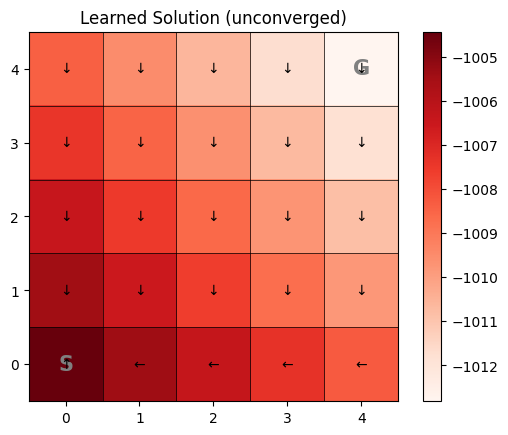

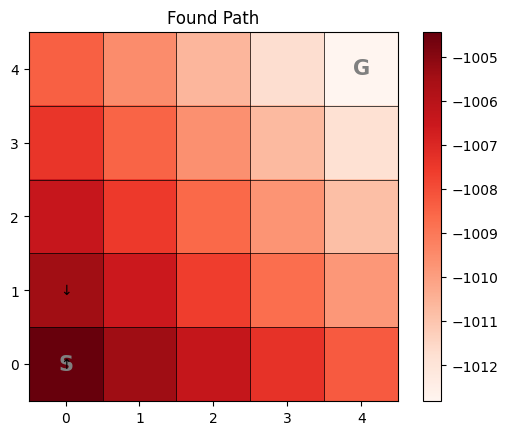

In [12]:
w = semi_gradient_Sarsa_0(env, n=100, epsilon=0.1, alpha=0.1, gamma=1, verbose=False)
plot_solution(w, title='Learned Solution (unconverged)')

Learning most likely did not converge! We need to reduce the learning rate.

Episodes: 100%|██████████| 100/100 [00:00<00:00, 1010.83it/s]


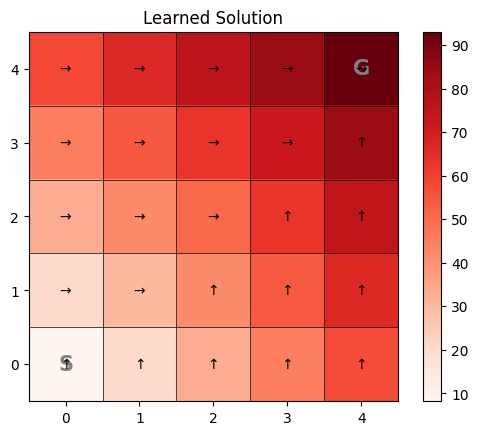

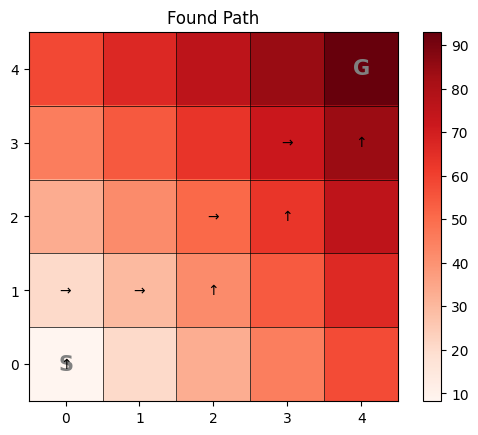

In [13]:
w = semi_gradient_Sarsa_0(env, n=100, epsilon=0.1, alpha=0.001, gamma=1, verbose=False)
plot_solution(w, title='Learned Solution')

Even a very small number of sampled episodes is enough to learn a value function that leads to a good policy.

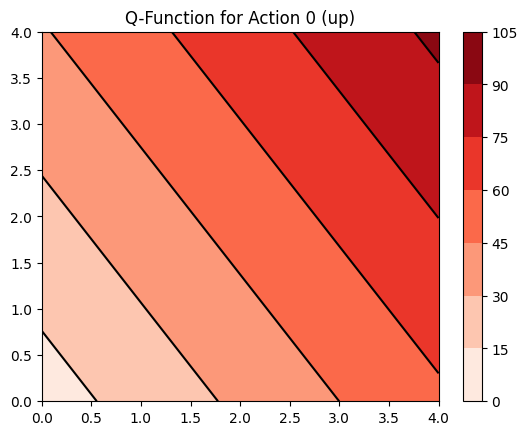

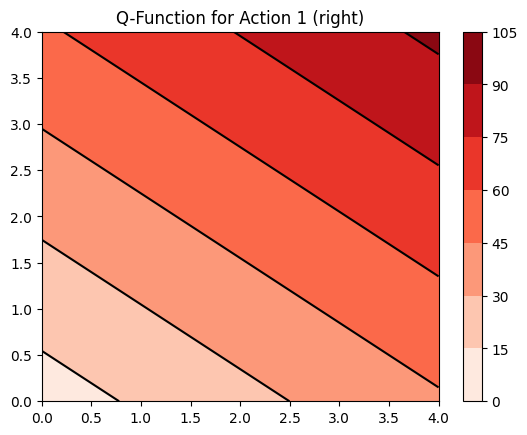

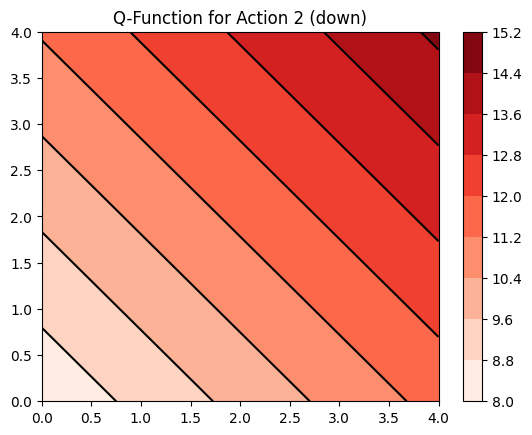

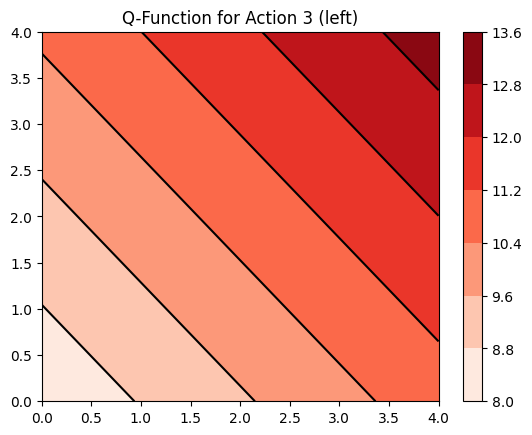

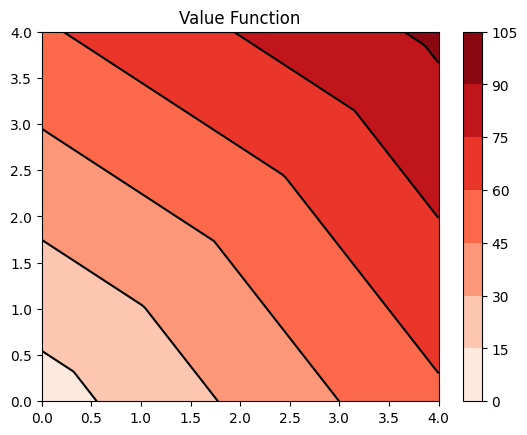

In [14]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(len(env.actions())):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    plt.contourf(X, Y, Z, cmap='Reds')
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.id2action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

Let's compare the learned value function with it with the optimal value function. Since we have model access, we can calculate it using value iteration.

### Experiment With Learning

The gym-classics implementation can return the weights after each episode.

**Note:** I use discounting so we can see how fast the goal is found!

In [15]:
from gym_classics2.algorithms.linear_approximation import semi_gradient_Sarsa_0
gym_classics2.algorithms.linear_approximation.state_features = state_features

w, history = semi_gradient_Sarsa_0(env, n=1000, epsilon=0.1, alpha=0.0001, gamma=.9, history=True)

Semi-Gradient SARSA(0): 100%|██████████| 1000/1000 [00:02<00:00, 399.04it/s]


Return over episodes.

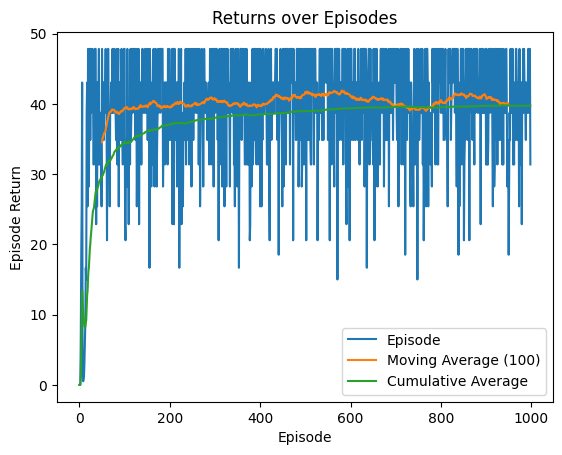

In [16]:
from gym_classics2.performance import plot_returns

plot_returns(history["returns"][1:], title="Returns over Episodes")

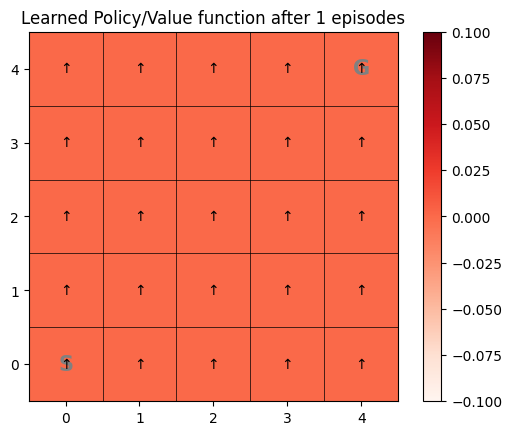

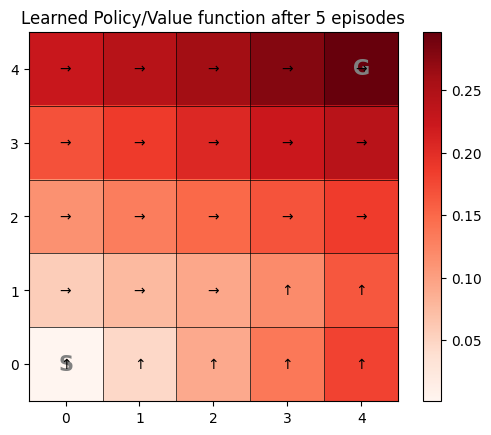

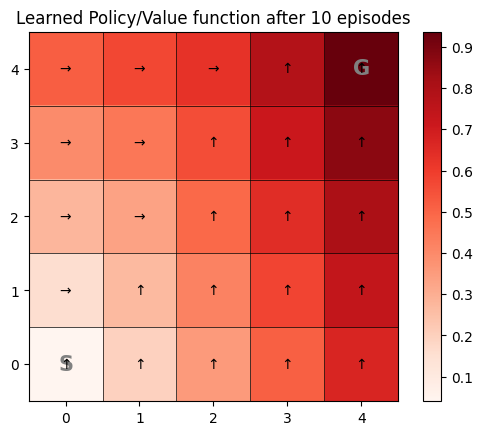

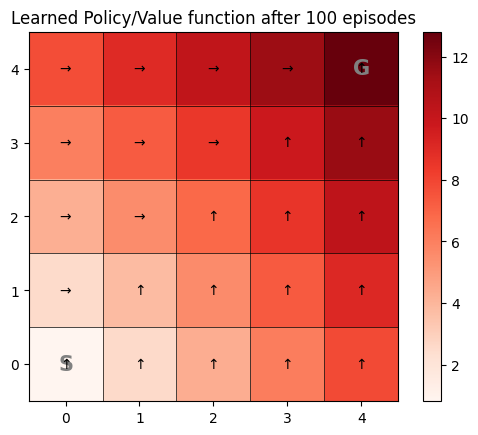

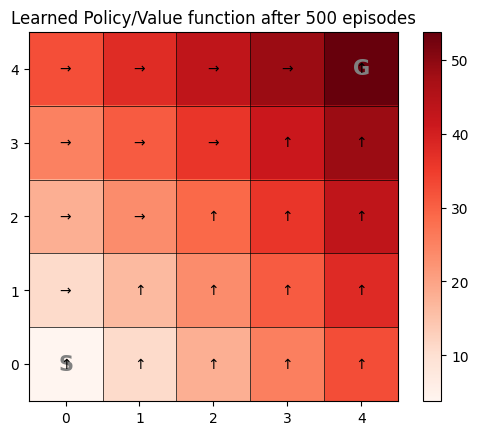

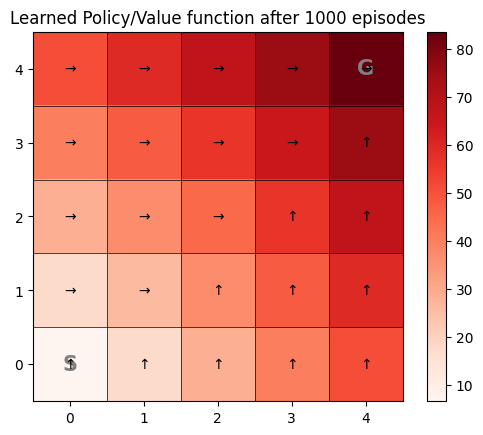

In [17]:
for i in [0,4, 9, 99, 499, 999]:
    plot_solution(history["ws"][i], title=f"Learned Policy/Value function after {i+1} episodes", path = False)    

Notes:

* Too large learning rate will destabilize the estimation over time! A schedule to reduce $\alpha$ over time can be used.
* $\epsilon$ can be reduced with a schedule over time to converge to the optimal policy (GLIE).


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)